In [1]:
# Install all the dependencies
#%%capture
#%pip -q install diffusers accelerate

In [2]:
import torch
from diffusers import DiffusionPipeline

## hugging face
https://huggingface.co/CompVis/stable-diffusion-v1-4

In [ ]:
# Define the Stable Diffusion XL pipeline
pipeline2 = DiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16,
)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

#device = torch.device("cpu")
print("Using Device:", device)
pipeline2 = pipeline2.to(device)

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [4]:
# Setting a seed would ensure reproducibility of the experiment.
generator = torch.Generator(device=device).manual_seed(42)

  0%|          | 0/50 [00:00<?, ?it/s]

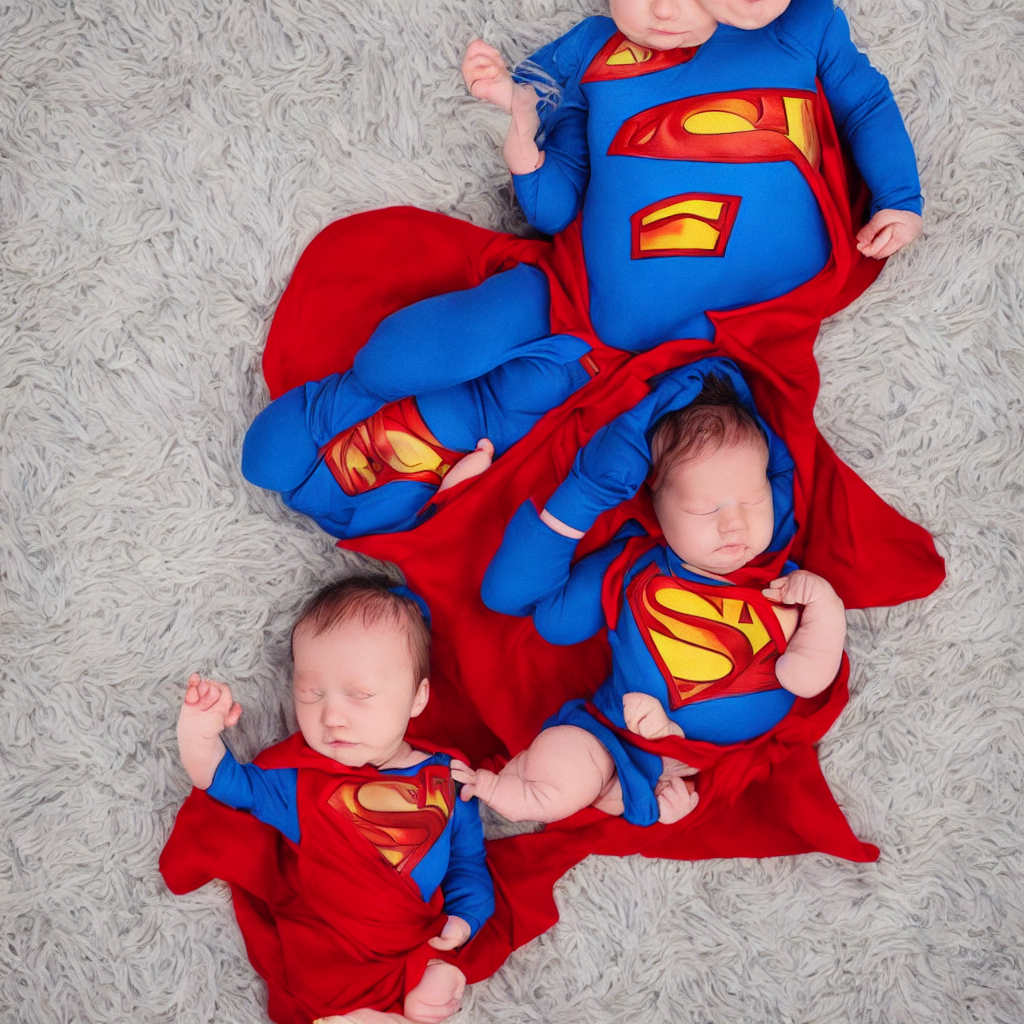

In [5]:
# Set the prompt
prompt = "baby in superman dress"
# Set the negative prompt, or leave it `None` if you don't want to use it
negative_prompt = None
# Add the callback to the pipeline, and execute the pipeline.
image = pipeline2(
    prompt,
    negative_prompt=negative_prompt,
    generator=generator,
    height=1024,
    width=1024,
)
image.images[0]

In [ ]:
# Imports
import torch
from diffusers import DiffusionPipeline


# Define the Stable Diffusion XL pipeline
pipeline = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
)
# Set the device for the pipeline
pipeline = pipeline.to(device)
# uncomment the following line if you encounter OOM issues
# pipeline.enable_sequential_cpu_offload()

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/1.68k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

vae_1_0/diffusion_pytorch_model.safetens(…):   0%|          | 0.00/335M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

In [ ]:
# Set the prompt
prompt = "baby in superman dress"
# Set the negative prompt, or leave it `None` if you don't want to use it
negative_prompt = None
# Add the callback to the pipeline, and execute the pipeline.
pipeline.unet = torch.compile(pipeline.unet, mode="reduce-overhead", fullgraph=True)
image = pipeline(
    prompt,
    negative_prompt=negative_prompt,
    generator=generator,
    height=1024,
    width=1024,
)

In [ ]:
image.images[0]

In [ ]:
# Set the prompt
prompt = "baby in superman dress, photorealistic, cinematic, ultra detailed"
# Set the negative prompt, or leave it `None` if you don't want to use it
negative_prompt = None
# Add the callback to the pipeline, and execute the pipeline.
image = pipeline(
    prompt,
    negative_prompt=negative_prompt,
    generator=generator,
    height=1024,
    width=1024,
)
image.images[0]

In [ ]:
pipeline

In [ ]:
pipeline2